In [1]:
!pip install awscli
!pip install gdown
!pip install parquet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.6/4.6 MB 46.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.5/14.5 MB 119.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 570.5/570.5 kB 7.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.8/86.8 kB 7.6 MB/s eta 0:00:00
  Attempting uninstall: rsa
    Found existing installation: rsa 4.9.1
    Uninstalling rsa-4.9.1:
      Successfully uninstalled rsa-4.9.1
  Attempting uninstall: docutils
    Found existing installation: docutils 0.21.2
    Uninstalling docutils-0.21.2:
      Successfully uninstalled docutils-0.21.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
sphinx 8.2.3 requires docutils<0.22,>=0.20, but you have docutils 0.19 which is incompatible.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 27.3 MB/s eta 0:00:00


In [2]:
## downloading raw files
!aws s3 sync \
  --no-sign-request \
  s3://cellpainting-gallery/cpg0003-rosetta/broad/workspace/preprocessed_data .

download: s3://cellpainting-gallery/cpg0003-rosetta/broad/workspace/preprocessed_data/CDRP-BBBC047-Bray/L1000/replicate_level_l1k_pclfc.csv.gz to CDRP-BBBC047-Bray/L1000/replicate_level_l1k_pclfc.csv.gz
download: s3://cellpainting-gallery/cpg0003-rosetta/broad/workspace/preprocessed_data/CDRP-BBBC047-Bray/L1000/replicate_level_l1k.csv.gz to CDRP-BBBC047-Bray/L1000/replicate_level_l1k.csv.gz
download: s3://cellpainting-gallery/cpg0003-rosetta/broad/workspace/preprocessed_data/CDRP-BBBC047-Bray/CellPainting/replicate_level_cp_normalized_variable_selected.csv.gz to CDRP-BBBC047-Bray/CellPainting/replicate_level_cp_normalized_variable_selected.csv.gz
download: s3://cellpainting-gallery/cpg0003-rosetta/broad/workspace/preprocessed_data/CDRP-BBBC047-Bray/L1000/treatment_level_l1k.csv.gz to CDRP-BBBC047-Bray/L1000/treatment_level_l1k.csv.gz
download: s3://cellpainting-gallery/cpg0003-rosetta/broad/workspace/preprocessed_data/CDRPBIO-BBBC036-Bray/CellPainting/replicate_level_cp_augmented.csv.g

In [3]:
## downloading curated files
!gdown 1Mz1VAHP2iBwdJk8uRrFB3UgaBoMnjZFD -O data.zip
!unzip data.zip

Downloading...
From (original): https://drive.google.com/uc?id=1Mz1VAHP2iBwdJk8uRrFB3UgaBoMnjZFD
From (redirected): https://drive.google.com/uc?id=1Mz1VAHP2iBwdJk8uRrFB3UgaBoMnjZFD&confirm=t&uuid=5825b19c-d253-4875-938d-feac1e2344c6
To: /content/data.zip
100% 2.73G/2.73G [00:20<00:00, 131MB/s]
Archive:  data.zip
   creating: curated/
  inflating: curated/.DS_Store       
  inflating: __MACOSX/curated/._.DS_Store  
   creating: curated/LINCS-Pilot1/
   creating: curated/CDRP-BBBC047-Bray/
   creating: curated/TA-ORF-BBBC037-Rohban/
   creating: curated/LUAD-BBBC041-Caicedo/
   creating: curated/LINCS-Pilot1/CellPainting/
  inflating: curated/LINCS-Pilot1/.DS_Store  
  inflating: __MACOSX/curated/LINCS-Pilot1/._.DS_Store  
   creating: curated/LINCS-Pilot1/L1000/
   creating: curated/CDRP-BBBC047-Bray/CellPainting/
  inflating: curated/CDRP-BBBC047-Bray/.DS_Store  
  inflating: __MACOSX/curated/CDRP-BBBC047-Bray/._.DS_Store  
   creating: curated/CDRP-BBBC047-Bray/L1000/
   creating: cur

In [4]:
## unzipping
!gunzip /content/LINCS-Pilot1/L1000/replicate_level_l1k.csv.gz
!gunzip /content/LINCS-Pilot1/CellPainting/replicate_level_cp_normalized.csv.gz

## Reading CellProfiler and L1000 datasets

In [5]:
import pyarrow.parquet as pa
import pandas as pd
import numpy as np
from sklearn.feature_selection import VarianceThreshold
from sklearn.preprocessing import RobustScaler, LabelEncoder
from sklearn.model_selection import train_test_split
import torch
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt

In [ ]:
l1000_curated = pa.read_table("/content/curated/LINCS-Pilot1/L1000/replicate_level_l1k.parquet").to_pandas()
cellpainting_curated = pa.read_table("/content/curated/LINCS-Pilot1/CellPainting/replicate_level_cp_augmented.parquet").to_pandas()

In [ ]:
l1000_raw = pd.read_csv("/content/LINCS-Pilot1/L1000/replicate_level_l1k.csv")
cellpainting_raw = pd.read_csv("/content/LINCS-Pilot1/CellPainting/replicate_level_cp_normalized.csv")

/tmp/ipython-input-1297697425.py:2: DtypeWarning: Columns (18,19,1820,1821) have mixed types. Specify dtype option on import or set low_memory=False.
  cellpainting_raw = pd.read_csv("/content/LINCS-Pilot1/CellPainting/replicate_level_cp_normalized.csv")


In [ ]:
l1000_curated["moa"] = l1000_raw["moa"].fillna("Unknown/Missing")
l1000_curated["pert_id_dose"] = l1000_raw["pert_id_dose"]

cellpainting_curated["moa"] = cellpainting_raw["moa"].fillna("Unknown/Missing")
cellpainting_curated["pert_id_dose"] = cellpainting_raw["Metadata_pert_id_dose"]
cellpainting_curated['pert_id_dose'] = cellpainting_curated['pert_id_dose'].astype(str).str.replace(r'\.0$', '', regex=True)

## Data preprocessing

In [ ]:
## intersections of permutation dose
pert_dose = set(l1000_curated["pert_id_dose"]) & set(cellpainting_curated["pert_id_dose"])
cellpainting_curated = cellpainting_curated[cellpainting_curated["pert_id_dose"].isin(pert_dose)]
l1000_curated = l1000_curated[l1000_curated["pert_id_dose"].isin(pert_dose)]

In [ ]:
class ZCASpherizer:
    def __init__(self, epsilon=1e-6):
        self.epsilon = epsilon
        self.mean_ = None
        self.W_ = None

    def fit(self, X):
        self.mean_ = np.mean(X, axis=0)
        X_centered = X - self.mean_
        sigma = np.dot(X_centered.T, X_centered) / (X.shape[0] - 1)
        U, S, _ = np.linalg.svd(sigma)
        inv_sqrt_S = np.diag(1.0 / np.sqrt(S + self.epsilon))
        self.W_ = np.dot(np.dot(U, inv_sqrt_S), U.T)
        return self

    def transform(self, X):
        return np.dot(X - self.mean_, self.W_.T)

In [ ]:
def preprocess_cp(df, meta_cols):
    numeric_df = df.drop(columns=meta_cols, errors='ignore').select_dtypes(include=['number'])
    meta_df = df[meta_cols]

    sel = VarianceThreshold(threshold=0.01)
    data_var = sel.fit_transform(numeric_df)
    current_cols = numeric_df.columns[sel.get_support()]
    data_df = pd.DataFrame(data_var, index=df.index, columns=current_cols)

    corr_matrix = data_df.corr().abs()
    upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
    to_drop = [c for c in upper.columns if any(upper[c] > 0.9)]
    data_corr = data_df.drop(columns=to_drop)

    valid_cols = (data_corr >= 0).all()
    data_corr = data_corr.loc[:, valid_cols]
    data_log = np.log1p(data_corr)

    controls = meta_df['pert_id_dose'].isin(['negcon'])

    if not controls.any():
        print("test")
        controls = pd.Series([True] * len(df), index=df.index)

    scaler = RobustScaler().fit(data_log.loc[controls])
    data_scaled = scaler.transform(data_log)

    spherizer = ZCASpherizer().fit(data_scaled[controls])
    data_final = spherizer.transform(data_scaled)

    data_final_df = pd.DataFrame(data_final, columns=data_corr.columns, index=df.index)

    return pd.concat([meta_df, data_final_df], axis=1)

cp_clean = preprocess_cp(cellpainting_curated, ['pert_id_dose', 'moa'])
cp_clean.loc[cp_clean['pert_id_dose'] == 'negcon', 'moa'] = 'Control vehicle'

In [ ]:
def preprocess_l1000(df, meta_cols):
    numeric_df = df.drop(columns=meta_cols, errors='ignore').select_dtypes(include=['number'])
    meta_df = df[meta_cols].reset_index(drop=True)
    return pd.concat([meta_df, numeric_df], axis=1)

l1000_clean = preprocess_l1000(l1000_curated, ['pert_id_dose', 'moa', 'Metadata_pert_iname'])


In [ ]:
cp_clean

,pert_id_dose,moa,Metadata_pert_dose_micromolar,Cells_AreaShape_Area,Cells_AreaShape_Center_X,Cells_AreaShape_Center_Y,Cells_Correlation_Correlation_Mito_AGP,Cells_Correlation_K_AGP_DNA,Cells_Correlation_K_AGP_ER,Cells_Correlation_K_AGP_Mito,...,Nuclei_Texture_Gabor_DNA_5,Nuclei_Texture_Gabor_ER_10,Nuclei_Texture_Gabor_ER_5,Nuclei_Texture_Gabor_Mito_10,Nuclei_Texture_Gabor_Mito_20,Nuclei_Texture_Gabor_RNA_5,Nuclei_Texture_SumAverage_DNA_10_0,Nuclei_Texture_SumAverage_RNA_10_0,Nuclei_Texture_SumVariance_DNA_10_0,Nuclei_Texture_SumVariance_RNA_10_0
0,negcon,Control vehicle,0.000000,-0.449317,1.460208,0.516201,-0.458090,1.357779,0.525699,-0.448443,...,-1.277198,0.238358,1.718353,0.410812,-0.532278,1.180720,0.706395,-0.144990,-2.405138,-0.919612
1,negcon,Control vehicle,0.000000,0.390307,2.004972,-0.663535,0.485942,-0.090003,-0.754736,-0.846952,...,-0.257038,0.144619,0.552136,0.320528,-0.557855,0.604546,0.272473,0.007671,-0.567817,-0.290793
2,negcon,Control vehicle,0.000000,1.143802,0.623908,-0.108644,-1.351115,0.952754,-0.694002,-0.635452,...,-1.419753,0.734237,0.232151,-2.192114,1.409148,1.318263,0.778526,-0.072141,-0.950091,-0.192183
3,negcon,Control vehicle,0.000000,1.050864,-1.792140,0.078524,-0.213537,0.725510,-0.205616,-0.356761,...,0.207941,-0.012050,0.932932,-0.647766,0.666449,1.032864,1.390114,-0.255599,-0.036382,-1.187550
4,negcon,Control vehicle,0.000000,-1.895510,1.518378,0.449943,-0.579086,0.269740,-1.243176,-0.220437,...,1.705310,-1.442286,1.030716,-0.151854,0.324009,-1.682629,1.055695,0.119915,-0.860347,-0.725684
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
52218,BRD-K61567297_3.33,toll-like receptor inhibitor,1466.326807,-2.603143,0.329185,-0.321060,0.229966,-2.662402,1.126111,0.010606,...,-1.919857,0.849155,-3.039819,-3.245973,-2.089147,-2.244041,0.606634,5.319059,-2.968476,0.179482
52219,BRD-K61567297_1.11,toll-like receptor inhibitor,747.207829,-1.362591,1.966603,0.362827,-0.441757,-2.776732,0.927910,-1.739513,...,-0.806800,1.005820,-0.028621,-0.424076,0.159696,-0.627231,0.870702,0.750990,1.089873,-0.532535
52220,BRD-K61567297_0.37,toll-like receptor inhibitor,315.080224,-1.990959,1.473120,1.194989,-0.701188,-0.826436,-0.626694,0.596930,...,-0.599250,-0.171150,-1.232958,-0.154335,0.576273,-0.089779,0.891441,1.042469,-0.295686,-0.581311
52221,BRD-K61567297_0.12,toll-like receptor inhibitor,116.413005,-1.989894,0.248977,-0.220017,-1.581608,-2.569863,3.386388,3.463092,...,-0.472786,0.579240,-1.549577,-3.265282,-1.546851,-0.992963,0.429297,0.185507,0.456221,-0.879232


In [ ]:
l1000_clean

,pert_id_dose,moa,Metadata_pert_iname,Metadata_pert_dose_micromolar,Metadata_pert_timepoint,PSME1,ATF1,RHEB,FOXO3,RHOA,...,CCP110,STK10,UGDH,SQOR,HEBP1,ATP11B,CD320,MLLT11,CEBPZ,CBR3
0,negcon,Control vehicle,DMSO,-666.000000,24,0.3547,-0.4940,-0.1721,-0.0339,-0.4355,...,-0.1345,-0.1423,0.1349,0.3684,-3.1025,-0.6226,-3.7452,-1.3157,1.0145,0.1046
1,negcon,Control vehicle,DMSO,-666.000000,24,-0.2130,0.4931,-0.8768,-0.6968,-1.7018,...,0.5892,3.2737,-15.1256,0.5294,-0.6672,3.7304,0.6153,-1.4900,0.9750,-1.8243
2,negcon,Control vehicle,DMSO,-666.000000,24,-0.3280,-0.4555,0.3819,-1.1447,0.0951,...,-0.2690,-1.0745,0.1349,-0.1003,-2.3632,-0.2763,0.4857,0.1338,-0.2992,1.1796
3,negcon,Control vehicle,DMSO,-666.000000,24,0.1175,-0.9678,-0.3185,0.4623,-0.2842,...,-0.5354,-0.9029,-15.0048,-0.2428,0.0595,-0.1896,0.8919,-1.2058,-0.2843,0.2155
4,BRD-K25114078_10,Nitric oxide synthase inhibitor,aminoguanidine,10.000000,24,0.5254,0.0000,-0.4691,0.3652,-1.0688,...,-0.6069,0.3590,-15.3090,-0.0670,-0.7765,-0.3680,0.9602,-1.4851,-0.3904,-0.3328
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
27832,BRD-A97502381_3.33,Methylmalonyl CoA mutase stimulant|Vitamin B,cyanocobalamin,3.333330,24,-1.4560,-1.0966,0.8633,-0.4426,2.3494,...,-7.1483,-0.4261,0.3652,0.1355,0.3702,-0.1814,0.3243,-1.0863,-12.9015,0.1211
27833,BRD-A97502381_1.11,Methylmalonyl CoA mutase stimulant|Vitamin B,cyanocobalamin,1.111110,24,0.5672,0.2946,-1.9837,-0.6680,0.5777,...,0.6573,1.5657,0.0000,0.5617,3.0291,0.7556,1.0516,-0.5138,0.4044,-0.3258
27834,BRD-A97502381_0.37,Methylmalonyl CoA mutase stimulant|Vitamin B,cyanocobalamin,0.370370,24,-0.9993,-0.6982,0.1973,-0.6394,0.1946,...,-0.8957,22.8667,0.6745,-2.2712,-0.6611,-0.4919,-0.1620,-0.6346,-0.9292,-0.0825
27835,BRD-A97502381_0.12,Methylmalonyl CoA mutase stimulant|Vitamin B,cyanocobalamin,0.123457,24,0.3532,-0.7262,-0.1420,0.6304,1.0234,...,0.0000,22.5149,-0.3457,-2.4435,0.4236,0.0097,0.3827,0.2203,-0.4916,-4.8720


In [ ]:
cp_metadata_cols = ["pert_id_dose", "moa"]
cp_feature_cols = [c for c in cp_clean.columns if c not in cp_metadata_cols]
cp_collapsed = (cp_clean.groupby(["pert_id_dose", "moa"], as_index=False)[cp_feature_cols].median())

In [ ]:
cp_collapsed

,pert_id_dose,moa,Metadata_pert_dose_micromolar,Cells_AreaShape_Area,Cells_AreaShape_Center_X,Cells_AreaShape_Center_Y,Cells_Correlation_Correlation_Mito_AGP,Cells_Correlation_K_AGP_DNA,Cells_Correlation_K_AGP_ER,Cells_Correlation_K_AGP_Mito,...,Nuclei_Texture_Gabor_DNA_5,Nuclei_Texture_Gabor_ER_10,Nuclei_Texture_Gabor_ER_5,Nuclei_Texture_Gabor_Mito_10,Nuclei_Texture_Gabor_Mito_20,Nuclei_Texture_Gabor_RNA_5,Nuclei_Texture_SumAverage_DNA_10_0,Nuclei_Texture_SumAverage_RNA_10_0,Nuclei_Texture_SumVariance_DNA_10_0,Nuclei_Texture_SumVariance_RNA_10_0
0,BRD-A00147595_0.04,insulin sensitizer|PPAR receptor partial agonist,40.327722,-0.228410,0.961839,0.219908,0.175110,-1.362806,1.469900,-0.061802,...,0.322228,0.466678,0.890277,-1.679618,0.238304,0.103540,-1.027659,-0.318703,0.955350,-0.479095
1,BRD-A00147595_0.12,insulin sensitizer|PPAR receptor partial agonist,116.413005,0.166998,-0.750021,1.222372,0.854299,-1.034699,0.395735,0.033443,...,-0.035254,0.856510,0.133127,0.068867,-0.094234,-0.256927,-1.706589,0.570603,1.120051,0.355887
2,BRD-A00147595_0.37,insulin sensitizer|PPAR receptor partial agonist,315.080224,1.104610,-0.815533,0.219327,0.245342,-0.622761,0.103137,-0.240481,...,-0.303618,-0.181609,-0.864275,-0.256664,0.313712,-0.244257,-1.485658,0.677956,1.876175,-0.399003
3,BRD-A00147595_1.11,insulin sensitizer|PPAR receptor partial agonist,747.207829,-0.731467,0.994886,-0.378820,0.670175,-0.337467,-0.280997,-0.160028,...,0.085192,0.502849,0.518304,0.443695,-0.254033,-0.755229,-1.323011,1.425167,0.850217,-0.159279
4,BRD-A00147595_10,insulin sensitizer|PPAR receptor partial agonist,2397.891071,1.599362,1.260497,-0.288318,0.915961,0.723741,0.030347,0.568917,...,0.532315,0.159152,-0.569449,1.431602,-0.201438,0.181306,-4.327403,1.304899,-0.014199,0.012966
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8365,BRD-M89827113_0.37,Unknown/Missing,315.080224,-0.051938,0.150913,-0.761184,-0.438810,0.318688,0.033340,-0.265201,...,-0.040648,0.792060,0.563725,0.240795,-0.483717,-0.059068,-0.404978,0.393863,-0.622887,-0.922252
8366,BRD-M89827113_1.11,Unknown/Missing,747.207829,-0.275157,0.240530,-0.578550,-0.478731,-0.095220,-0.237990,-0.043273,...,1.143453,1.368616,0.226803,-0.198417,-1.254627,-0.117771,0.087965,0.824029,-0.515196,-0.759114
8367,BRD-M89827113_10,Unknown/Missing,2397.891071,0.281231,0.922686,-0.093958,-0.556338,-1.008902,-0.315052,0.127667,...,0.874479,0.166057,0.556707,-1.694353,-1.817240,0.272409,0.494893,-0.092293,-1.488309,-1.568619
8368,BRD-M89827113_3.33,Unknown/Missing,1466.326807,-0.679709,0.942095,0.987593,0.119348,0.831903,-0.499015,-0.100054,...,0.393751,1.186493,0.495131,0.237144,-0.834862,-0.399062,0.279261,0.132852,-0.754925,-1.360546


In [ ]:
cp_collapsed.shape

(8370, 165)

In [ ]:
l1000_metadata_cols = ["pert_id_dose", "moa", "Metadata_pert_iname"]
l1000_feature_cols = [c for c in l1000_clean.columns if c not in l1000_metadata_cols]
l1000_collapsed = (l1000_clean.groupby(["pert_id_dose", "moa", 'Metadata_pert_iname'], as_index=False)[l1000_feature_cols].median())

In [ ]:
l1000_collapsed

,pert_id_dose,moa,Metadata_pert_iname,Metadata_pert_dose_micromolar,Metadata_pert_timepoint,PSME1,ATF1,RHEB,FOXO3,RHOA,...,CCP110,STK10,UGDH,SQOR,HEBP1,ATP11B,CD320,MLLT11,CEBPZ,CBR3
0,BRD-A00147595_0.04,Insulin sensitizer|PPAR receptor partial agonist,balaglitazone,0.041152,24.0,0.27330,-0.26665,-0.92300,0.51205,-0.47895,...,0.30145,9.40520,-0.44080,-0.58265,-0.23400,-0.30845,-0.14740,0.06815,-0.07060,-0.14170
1,BRD-A00147595_0.12,Insulin sensitizer|PPAR receptor partial agonist,balaglitazone,0.123457,24.0,-0.35300,-0.48955,-0.80215,0.05945,-0.42010,...,0.75330,0.54935,-0.31185,-0.12695,-0.46920,-0.17605,-0.02020,-0.19645,0.26990,-0.50540
2,BRD-A00147595_0.37,Insulin sensitizer|PPAR receptor partial agonist,balaglitazone,0.370370,24.0,-0.64670,0.59140,0.14585,-0.20135,-0.35540,...,-1.17155,0.73225,-0.43145,1.05560,-0.30200,0.62625,-1.01870,-1.29965,-0.17315,-0.74690
3,BRD-A00147595_1.11,Insulin sensitizer|PPAR receptor partial agonist,balaglitazone,1.111110,24.0,0.54635,-0.14445,0.40340,-0.58255,-0.60070,...,-0.00515,-0.42090,0.00000,-0.00755,-0.51055,0.31425,-0.03145,0.03065,0.62790,0.01540
4,BRD-A00147595_10,Insulin sensitizer|PPAR receptor partial agonist,balaglitazone,10.000000,24.0,-0.99245,0.25305,-1.27005,-0.27355,-0.54365,...,-0.69495,0.33235,-0.44080,-0.19415,-0.17835,1.10170,-0.43840,-0.21005,-0.60020,-0.82785
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8365,BRD-M89827113_0.37,Potassium channel activator,levcromakalim,0.370370,24.0,-0.01210,0.81400,-0.16750,-0.49810,-0.68420,...,-0.29550,-0.49470,-0.13890,0.31990,0.06300,0.10970,-0.11160,-0.33540,-0.25370,0.23510
8366,BRD-M89827113_1.11,Potassium channel activator,levcromakalim,1.111110,24.0,1.22450,0.77190,-0.13960,-0.33590,-0.38770,...,-0.27800,-0.42220,0.00000,-3.17470,0.79620,-0.98710,-0.35040,0.24410,0.47000,-1.03960
8367,BRD-M89827113_10,Potassium channel activator,levcromakalim,10.000000,24.0,-0.46330,0.04930,0.51790,-1.11710,-1.72400,...,-0.06370,1.66870,0.38710,-0.04000,0.66030,-0.14040,1.37250,0.11520,0.53540,0.73220
8368,BRD-M89827113_3.33,Potassium channel activator,levcromakalim,3.333330,24.0,-1.06180,0.22825,0.53690,3.68445,-0.34415,...,-0.99300,11.45340,-0.77440,-1.39280,-0.50910,0.74520,-0.63865,0.07675,-0.28350,2.75985


In [ ]:
# merging non-controls

lincs_df = pd.merge(
    cp_collapsed,
    l1000_collapsed,
    on=['pert_id_dose', 'moa'],
    how='inner',
    suffixes=('_cp', '_l1000')
)

## processing pipes in moa
lincs_df['moa'] = lincs_df['moa'].str.split('|')
lincs_df = lincs_df.explode('moa').reset_index(drop=True)
lincs_df.insert(0, 'Metadata_pert_iname', lincs_df.pop('Metadata_pert_iname'))

In [ ]:
# merging non-controls
cp_mask = (cp_clean['pert_id_dose'] == 'negcon') & (cp_clean['moa'] == 'Control vehicle')
l1_mask = (l1000_clean['pert_id_dose'] == 'negcon') & (l1000_clean['moa'] == 'Control vehicle')


merged_treatments = pd.merge(
    cp_clean[~cp_mask],
    l1000_clean[~l1_mask],
    on=['pert_id_dose', 'moa'],
    how='inner',
    suffixes=('_cp', '_l1000')
)

n_samples = 10000
cp_ctl = cp_clean[cp_mask].sample(n=n_samples, replace=True).reset_index(drop=True)
l1_ctl = l1000_clean[l1_mask].sample(n=n_samples, replace=True).reset_index(drop=True)

cp_ctl['join_key'] = range(n_samples)
l1_ctl['join_key'] = range(n_samples)

merged_controls = pd.merge(
    cp_ctl,
    l1_ctl,
    on=['join_key', 'pert_id_dose', 'moa'],
    suffixes=('_cp', '_l1000')
).drop(columns='join_key')

# combine controls and non-controls
original_lincs_df = pd.concat([merged_treatments, merged_controls], axis=0, ignore_index=True)

## processing pipes in moa
original_lincs_df['moa'] = original_lincs_df['moa'].str.split('|')
original_lincs_df = original_lincs_df.explode('moa').reset_index(drop=True)
original_lincs_df.insert(0, 'Metadata_pert_iname', original_lincs_df.pop('Metadata_pert_iname'))

In [ ]:
lincs_df

,Metadata_pert_iname,pert_id_dose,moa,Metadata_pert_dose_micromolar_cp,Cells_AreaShape_Area,Cells_AreaShape_Center_X,Cells_AreaShape_Center_Y,Cells_Correlation_Correlation_Mito_AGP,Cells_Correlation_K_AGP_DNA,Cells_Correlation_K_AGP_ER,...,CCP110,STK10,UGDH,SQOR,HEBP1,ATP11B,CD320,MLLT11,CEBPZ,CBR3
0,xl888,BRD-A03506276_0.04,HSP inhibitor,40.327722,16.599833,1.223096,0.210616,2.388847,-1.757935,3.863777,...,0.3855,-0.0476,0.6745,2.0015,-0.3488,-1.0579,0.0000,1.7661,0.3230,0.8535
1,xl888,BRD-A03506276_0.12,HSP inhibitor,116.413005,2.650821,0.666668,-2.258477,2.803151,-2.386505,1.863146,...,-3.0818,-0.8477,0.0000,1.3240,-2.1050,-0.1508,-3.6340,-0.1748,1.2507,1.0327
2,xl888,BRD-A03506276_0.37,HSP inhibitor,315.080224,2.302125,1.914136,0.041269,2.554510,-2.034628,0.582053,...,-2.9469,0.1647,-0.4881,-1.8113,-2.3234,0.1776,-5.2087,0.9130,0.0425,1.6787
3,xl888,BRD-A03506276_1.11,HSP inhibitor,747.207829,3.295396,0.624840,-2.187152,5.887535,-2.765656,0.071858,...,-1.5644,-0.6832,-0.5972,-0.6815,-1.7890,-0.8078,-4.1923,1.6325,0.1768,2.7330
4,xl888,BRD-A03506276_10,HSP inhibitor,2397.891071,3.262829,1.128574,-0.642617,11.334266,-3.953225,-0.047861,...,-3.1698,-1.0527,-0.7062,-1.4078,3.4454,0.0324,-4.0651,2.6607,-0.3859,1.3973
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1555,linifanib,BRD-K99749624_10,PDGFR tyrosine kinase receptor inhibitor,2397.891071,-0.337002,1.799915,0.574922,0.310777,-1.343356,-1.150597,...,0.1592,0.1060,-1.5231,-3.1574,0.0628,-0.7043,-0.6857,-0.7112,-0.0403,-0.7528
1556,linifanib,BRD-K99749624_10,VEGFR inhibitor,2397.891071,-0.337002,1.799915,0.574922,0.310777,-1.343356,-1.150597,...,0.1592,0.1060,-1.5231,-3.1574,0.0628,-0.7043,-0.6857,-0.7112,-0.0403,-0.7528
1557,linifanib,BRD-K99749624_3.33,PDGFR tyrosine kinase receptor inhibitor,1466.326807,0.905329,0.498549,0.140473,-0.489129,0.631547,0.457599,...,0.6318,0.0210,-1.3111,0.1952,0.2184,0.0742,0.2618,-1.2834,-0.3961,-1.0396
1558,linifanib,BRD-K99749624_3.33,VEGFR inhibitor,1466.326807,0.905329,0.498549,0.140473,-0.489129,0.631547,0.457599,...,0.6318,0.0210,-1.3111,0.1952,0.2184,0.0742,0.2618,-1.2834,-0.3961,-1.0396


In [ ]:
original_lincs_df

,Metadata_pert_iname,pert_id_dose,moa,Metadata_pert_dose_micromolar_cp,Cells_AreaShape_Area,Cells_AreaShape_Center_X,Cells_AreaShape_Center_Y,Cells_Correlation_Correlation_Mito_AGP,Cells_Correlation_K_AGP_DNA,Cells_Correlation_K_AGP_ER,...,CCP110,STK10,UGDH,SQOR,HEBP1,ATP11B,CD320,MLLT11,CEBPZ,CBR3
0,methoxsalen,BRD-K63430059_10,DNA synthesis inhibitor,2397.891071,1.034360,0.931702,0.035996,-0.337933,-0.913096,2.364428,...,-0.8577,-1.4084,0.6745,0.9106,8.4765,-0.0719,-0.2910,-0.2793,-0.4814,0.1015
1,methoxsalen,BRD-K63430059_10,DNA synthesis inhibitor,2397.891071,1.034360,0.931702,0.035996,-0.337933,-0.913096,2.364428,...,2.9780,-1.2521,0.3157,-0.0888,0.1417,-0.9396,-0.6427,-3.7500,-1.9648,0.7033
2,methoxsalen,BRD-K63430059_10,DNA synthesis inhibitor,2397.891071,1.034360,0.931702,0.035996,-0.337933,-0.913096,2.364428,...,-0.8696,26.1331,1.3180,1.6880,1.1140,0.8982,0.2489,-0.9773,-0.0831,-0.2449
3,methoxsalen,BRD-K63430059_3.33,DNA synthesis inhibitor,1466.326807,-0.728949,0.231320,0.145304,-0.642461,0.407158,1.079414,...,0.1402,-1.2122,0.2974,0.8817,-1.7789,-0.7722,-0.5473,0.9592,-1.1369,1.0811
4,methoxsalen,BRD-K63430059_3.33,DNA synthesis inhibitor,1466.326807,-0.728949,0.231320,0.145304,-0.642461,0.407158,1.079414,...,-0.0111,-0.4770,-0.5652,-0.0605,-0.8610,-1.0386,-0.0133,0.9501,-0.4043,0.6152
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32622,DMSO,negcon,Control vehicle,0.000000,-0.164679,0.849689,0.732062,-1.850535,-0.592332,-1.818842,...,2.8629,2.3326,-0.9308,-0.0744,7.5605,1.5980,-0.1137,-0.8717,-2.5779,0.2563
32623,DMSO,negcon,Control vehicle,0.000000,3.104266,0.292030,-0.713013,-1.350725,0.460112,-1.641749,...,-0.2467,0.2957,0.0000,1.0182,-1.9872,-0.7777,-4.7553,-0.4659,-0.8030,-1.3335
32624,DMSO,negcon,Control vehicle,0.000000,0.050398,0.542921,-1.067184,0.036968,-1.025236,-0.077644,...,-0.2350,-0.2502,0.5349,1.7011,0.8380,-0.3792,-0.5238,-0.4933,0.3432,0.2450
32625,DMSO,negcon,Control vehicle,0.000000,-1.615165,1.711098,2.040119,-0.463684,-0.721836,-0.474753,...,-0.2849,0.2576,-1.7315,-4.7565,-0.7243,0.4042,-0.1900,-0.6454,-1.3677,0.0000


## Data prep for ML

In [ ]:
def prepare_data(df):
    unique_treatments = df[df['Metadata_pert_iname'] != 'DMSO']['Metadata_pert_iname'].unique()
    train_treats, test_treats = train_test_split(unique_treatments, test_size=0.2, random_state=42)

    train_mask = df['Metadata_pert_iname'].isin(train_treats)
    test_mask = df['Metadata_pert_iname'].isin(test_treats)

    train_df = df[train_mask].reset_index(drop=True)
    test_df = df[test_mask].reset_index(drop=True)

    le = LabelEncoder()
    le.fit(unique_treatments)

    return train_df, test_df, le



In [ ]:
train_df, test_df, label_encoder = prepare_data(final_df)

In [ ]:
lincs_df['Metadata_pert_iname'].nunique()

225

In [ ]:
pert_moa = dict(zip(original_lincs_df['Metadata_pert_iname'], original_lincs_df['moa']))

In [ ]:
pert_moa

{'methoxsalen': 'DNA synthesis inhibitor',
 'semaxanib': 'VEGFR inhibitor',
 'gefitinib': 'EGFR inhibitor',
 'BI-2536': 'PLK inhibitor',
 'PHA-793887': 'CDK inhibitor',
 'cordycepin': 'DNA inhibitor',
 'azd1480': 'JAK inhibitor',
 'afatinib': 'EGFR inhibitor',
 'amuvatinib': 'RET tyrosine kinase inhibitor',
 'ifosfamide': 'DNA alkylating agent',
 'IKK-2-inhibitor-V': 'NFkB pathway inhibitor',
 'alisertib': 'Aurora kinase inhibitor',
 'su014813': 'VEGFR inhibitor',
 'crizotinib': 'ALK tyrosine kinase receptor inhibitor',
 'enzastaurin': 'PKC inhibitor',
 'chlorpropamide': 'ATP channel blocker',
 'honokiol': 'AKT inhibitor',
 'cepharanthine': 'NFkB pathway inhibitor',
 'CI-976': 'ACAT inhibitor',
 'torcitabine': 'DNA polymerase inhibitor',
 'EX-527': 'SIRT inhibitor',
 'vandetanib': 'VEGFR inhibitor',
 'dequalinium': 'PKC inhibitor',
 'ly2157299': 'TGF beta receptor inhibitor',
 'nesbuvir': 'RNA polymerase inhibitor',
 'taselisib': 'PI3K inhibitor',
 'proglumide': 'CCK receptor antagonis

In [ ]:
train_df

,Metadata_pert_iname,pert_id_dose,moa,Metadata_pert_dose_micromolar_cp,Cells_AreaShape_Area,Cells_AreaShape_Center_X,Cells_AreaShape_Center_Y,Cells_Correlation_Correlation_Mito_AGP,Cells_Correlation_K_AGP_DNA,Cells_Correlation_K_AGP_ER,...,CCP110,STK10,UGDH,SQOR,HEBP1,ATP11B,CD320,MLLT11,CEBPZ,CBR3
0,xl888,BRD-A03506276_0.04,HSP inhibitor,40.327722,16.599833,1.223096,0.210616,2.388847,-1.757935,3.863777,...,0.3855,-0.0476,0.6745,2.0015,-0.3488,-1.0579,0.0000,1.7661,0.3230,0.8535
1,xl888,BRD-A03506276_0.12,HSP inhibitor,116.413005,2.650821,0.666668,-2.258477,2.803151,-2.386505,1.863146,...,-3.0818,-0.8477,0.0000,1.3240,-2.1050,-0.1508,-3.6340,-0.1748,1.2507,1.0327
2,xl888,BRD-A03506276_0.37,HSP inhibitor,315.080224,2.302125,1.914136,0.041269,2.554510,-2.034628,0.582053,...,-2.9469,0.1647,-0.4881,-1.8113,-2.3234,0.1776,-5.2087,0.9130,0.0425,1.6787
3,xl888,BRD-A03506276_1.11,HSP inhibitor,747.207829,3.295396,0.624840,-2.187152,5.887535,-2.765656,0.071858,...,-1.5644,-0.6832,-0.5972,-0.6815,-1.7890,-0.8078,-4.1923,1.6325,0.1768,2.7330
4,xl888,BRD-A03506276_10,HSP inhibitor,2397.891071,3.262829,1.128574,-0.642617,11.334266,-3.953225,-0.047861,...,-3.1698,-1.0527,-0.7062,-1.4078,3.4454,0.0324,-4.0651,2.6607,-0.3859,1.3973
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1262,linifanib,BRD-K99749624_1.11,VEGFR inhibitor,747.207829,-0.136255,-1.293644,0.076537,-1.286381,-1.332784,3.727496,...,0.2995,0.5837,-0.3445,0.4559,1.1491,-0.1262,-0.2003,-0.9586,1.3228,-0.5017
1263,linifanib,BRD-K99749624_10,PDGFR tyrosine kinase receptor inhibitor,2397.891071,-0.337002,1.799915,0.574922,0.310777,-1.343356,-1.150597,...,0.1592,0.1060,-1.5231,-3.1574,0.0628,-0.7043,-0.6857,-0.7112,-0.0403,-0.7528
1264,linifanib,BRD-K99749624_10,VEGFR inhibitor,2397.891071,-0.337002,1.799915,0.574922,0.310777,-1.343356,-1.150597,...,0.1592,0.1060,-1.5231,-3.1574,0.0628,-0.7043,-0.6857,-0.7112,-0.0403,-0.7528
1265,linifanib,BRD-K99749624_3.33,PDGFR tyrosine kinase receptor inhibitor,1466.326807,0.905329,0.498549,0.140473,-0.489129,0.631547,0.457599,...,0.6318,0.0210,-1.3111,0.1952,0.2184,0.0742,0.2618,-1.2834,-0.3961,-1.0396


In [ ]:
moa_list = train_df['moa'].unique()
moa_list.sort()

In [ ]:
moa_list

array(['3-ketoacyl CoA thiolase inhibitor',
       '3beta-hydroxy-delta5-steroid dehydrogenase inhibitor',
       '5 alpha reductase inhibitor', 'ACAT inhibitor', 'AKT inhibitor',
       'ALK tyrosine kinase receptor inhibitor', 'AMPK activator',
       'ATP channel blocker', 'ATPase inhibitor',
       'Aurora kinase inhibitor', 'BCL inhibitor',
       'Bcr-Abl kinase inhibitor', 'CC chemokine receptor antagonist',
       'CCK receptor antagonist', 'CD antagonist', 'CDK inhibitor',
       'CFTR channel antagonist', 'CMV terminase inhibitor',
       'CRTH receptor antagonist', 'DNA alkylating agent',
       'DNA directed DNA polymerase inhibitor', 'DNA inhibitor',
       'DNA methyltransferase inhibitor', 'DNA polymerase inhibitor',
       'DNA synthesis inhibitor', 'EGFR inhibitor', 'FGFR inhibitor',
       'FLT3 inhibitor', 'GABA receptor antagonist',
       'GABA receptor modulator', 'GABA uptake inhibitor',
       'GAT inhibitor', 'GK0582 inhibitor', 'HCN channel blocker',
       'H

In [ ]:
len(moa_list)

72

In [ ]:
moa_to_idx = {moa: idx for idx, moa in enumerate(moa_list)}
moa_to_idx

{'3-ketoacyl CoA thiolase inhibitor': 0,
 '3beta-hydroxy-delta5-steroid dehydrogenase inhibitor': 1,
 '5 alpha reductase inhibitor': 2,
 'ACAT inhibitor': 3,
 'AKT inhibitor': 4,
 'ALK tyrosine kinase receptor inhibitor': 5,
 'AMPK activator': 6,
 'ATP channel blocker': 7,
 'ATPase inhibitor': 8,
 'Aurora kinase inhibitor': 9,
 'BCL inhibitor': 10,
 'Bcr-Abl kinase inhibitor': 11,
 'CC chemokine receptor antagonist': 12,
 'CCK receptor antagonist': 13,
 'CD antagonist': 14,
 'CDK inhibitor': 15,
 'CFTR channel antagonist': 16,
 'CMV terminase inhibitor': 17,
 'CRTH receptor antagonist': 18,
 'DNA alkylating agent': 19,
 'DNA directed DNA polymerase inhibitor': 20,
 'DNA inhibitor': 21,
 'DNA methyltransferase inhibitor': 22,
 'DNA polymerase inhibitor': 23,
 'DNA synthesis inhibitor': 24,
 'EGFR inhibitor': 25,
 'FGFR inhibitor': 26,
 'FLT3 inhibitor': 27,
 'GABA receptor antagonist': 28,
 'GABA receptor modulator': 29,
 'GABA uptake inhibitor': 30,
 'GAT inhibitor': 31,
 'GK0582 inhib

In [ ]:
class LincsDataset(Dataset):
    def __init__(self, df, label_encoder):
        self.cp_data = df.iloc[:, 3:168].values.astype(np.float32)
        self.l1000_data = df.iloc[:, 168:].values.astype(np.float32)
        self.labels = label_encoder.transform(df['Metadata_pert_iname'].values)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return (torch.tensor(self.cp_data[idx]),
                torch.tensor(self.l1000_data[idx]),
                torch.tensor(self.labels[idx]))

In [ ]:
mapping_df = pd.DataFrame()
mapping_df['Metadata_pert_iname'] = label_encoder.classes_
mapping_df['moa'] = mapping_df['Metadata_pert_iname'].map(pert_moa)
mapping_df['index']=mapping_df.index
mapping_df['unique_moa_label'] = mapping_df['moa'].map(moa_to_idx)
mapping_df['unique_moa_label'] = mapping_df['unique_moa_label'].fillna(0).astype(int)
mapping_df

,Metadata_pert_iname,moa,index,unique_moa_label
0,3-amino-benzamide,PARP inhibitor,0,49
1,ABT-737,BCL inhibitor,1,10
2,AZ-628,RAF inhibitor,2,59
3,AZD-5438,CDK inhibitor,3,15
4,AZD-8330,MEK inhibitor,4,45
...,...,...,...,...
219,vicriviroc,CC chemokine receptor antagonist,219,12
220,volasertib,PLK inhibitor,220,54
221,xl888,HSP inhibitor,221,39
222,z160,N-type calcium channel blocker,222,46


In [ ]:
label_dict = dict(zip(mapping_df['index'], mapping_df['unique_moa_label']))
label_dict

{0: 49,
 1: 10,
 2: 59,
 3: 15,
 4: 45,
 5: 54,
 6: 31,
 7: 3,
 8: 67,
 9: 70,
 10: 63,
 11: 54,
 12: 48,
 13: 35,
 14: 71,
 15: 4,
 16: 45,
 17: 15,
 18: 8,
 19: 13,
 20: 35,
 21: 51,
 22: 33,
 23: 25,
 24: 5,
 25: 9,
 26: 24,
 27: 39,
 28: 15,
 29: 12,
 30: 14,
 31: 60,
 32: 5,
 33: 62,
 34: 0,
 35: 24,
 36: 38,
 37: 3,
 38: 22,
 39: 57,
 40: 41,
 41: 18,
 42: 26,
 43: 4,
 44: 0,
 45: 25,
 46: 61,
 47: 35,
 48: 21,
 49: 43,
 50: 55,
 51: 48,
 52: 0,
 53: 0,
 54: 70,
 55: 20,
 56: 70,
 57: 25,
 58: 69,
 59: 48,
 60: 21,
 61: 29,
 62: 7,
 63: 55,
 64: 34,
 65: 32,
 66: 55,
 67: 55,
 68: 29,
 69: 45,
 70: 21,
 71: 5,
 72: 59,
 73: 19,
 74: 35,
 75: 25,
 76: 37,
 77: 34,
 78: 22,
 79: 53,
 80: 13,
 81: 47,
 82: 8,
 83: 15,
 84: 36,
 85: 2,
 86: 20,
 87: 37,
 88: 35,
 89: 53,
 90: 25,
 91: 48,
 92: 53,
 93: 29,
 94: 23,
 95: 61,
 96: 22,
 97: 24,
 98: 61,
 99: 41,
 100: 2,
 101: 24,
 102: 11,
 103: 70,
 104: 65,
 105: 29,
 106: 25,
 107: 70,
 108: 34,
 109: 4,
 110: 51,
 111: 4,
 112: 51,

## Learning

- Use different encoders (autoencoder) and latent representations
- MOA prediction using logistic regressor and MLP
- Paper uses basic concatenation of L1000 and cell profiler data that gets vectorized, see paper's Github for more information regarding MOA prediction

In [ ]:
import torch.nn as nn
import torch.nn.functional as F

In [ ]:
class LateFusionContrastive(nn.Module):
    def __init__(self, cp_dim, gene_dim, embed_dim=6, dropout_rate=0.5):
        super().__init__()

        self.cp_encoder = nn.Sequential(
            nn.Linear(cp_dim, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            nn.Linear(512, 256)
        )

        self.gene_encoder = nn.Sequential(
            nn.Linear(gene_dim, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            nn.Linear(512, 256)
        )

        self.fusion_head = nn.Sequential(
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            nn.Linear(256, embed_dim)
        )

    def forward(self, x_cp, x_gene):
        h1 = self.cp_encoder(x_cp)
        h2 = self.gene_encoder(x_gene)
        fused = torch.cat((h1, h2), dim=1)
        embedding = self.fusion_head(fused)
        return F.normalize(embedding, p=2, dim=1)

In [ ]:
class SimpleSupConLoss(nn.Module):
    def __init__(self, temperature=0.07):
        super().__init__()
        self.temperature = temperature

    def forward(self, features, labels):
        device = features.device
        batch_size = features.shape[0]

        labels = labels.contiguous().view(-1, 1)
        mask = torch.eq(labels, labels.T).float().to(device)

        logits_mask = torch.scatter(
            torch.ones_like(mask),
            1,
            torch.arange(batch_size).view(-1, 1).to(device),
            0
        )
        mask = mask * logits_mask

        anchor_dot_contrast = torch.div(
            torch.matmul(features, features.T),
            self.temperature)

        logits_max, _ = torch.max(anchor_dot_contrast, dim=1, keepdim=True)
        logits = anchor_dot_contrast - logits_max.detach()

        exp_logits = torch.exp(logits) * logits_mask
        log_prob = logits - torch.log(exp_logits.sum(1, keepdim=True) + 1e-6)

        mask_sum = mask.sum(1)
        valid_mask = mask_sum > 0

        if valid_mask.sum() == 0:
            return torch.tensor(0.0, requires_grad=True).to(device)

        mean_log_prob_pos = (mask[valid_mask] * log_prob[valid_mask]).sum(1) / mask_sum[valid_mask]

        loss = - mean_log_prob_pos
        return loss.mean()

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

cp_dim = 165
gene_dim = final_df.shape[1] - 168
patience = 5
min_delta = 0.001
best_loss = float('inf')
counter = 0

train_history = []
val_history = []

train_dataset = LincsDataset(train_df, label_encoder)
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)

test_dataset = LincsDataset(test_df, label_encoder)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

model = LateFusionContrastive(cp_dim, gene_dim, dropout_rate=0.5).to(device)
criterion = SimpleSupConLoss(temperature=0.1)

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-4,
    weight_decay=1e-4
)

epochs = 100

for epoch in range(epochs):
    model.train()
    train_loss = 0
    train_embeddings = []
    train_labels = []
    for batch_cp, batch_gene, batch_labels in train_loader:
        batch_cp, batch_gene, batch_labels = batch_cp.to(device), batch_gene.to(device), batch_labels.to(device)

        embeddings = model(batch_cp, batch_gene)
        loss = criterion(embeddings, batch_labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        train_loss += loss.item()
        train_embeddings.append(embeddings.detach().cpu().numpy())
        train_labels.append(batch_labels.cpu().numpy())

    train_embeddings = np.concatenate(train_embeddings, axis=0)
    train_labels = np.concatenate(train_labels, axis=0)

    avg_train_loss = train_loss / len(train_loader)
    train_history.append(avg_train_loss)

    np.save("train_embeddings.npy", train_embeddings)
    np.save("train_labels.npy", train_labels)

    model.eval()
    val_loss = 0
    test_embeddings = []
    test_labels = []
    with torch.no_grad():
        for batch_cp, batch_gene, batch_labels in test_loader:
            batch_cp, batch_gene, batch_labels = batch_cp.to(device), batch_gene.to(device), batch_labels.to(device)
            embeddings = model(batch_cp, batch_gene)
            loss = criterion(embeddings, batch_labels)
            val_loss += loss.item()
            test_embeddings.append(embeddings.detach().cpu().numpy())
            test_labels.append(batch_labels.cpu().numpy())

    test_embeddings = np.concatenate(test_embeddings, axis=0)
    test_labels = np.concatenate(test_labels, axis=0)

    np.save("test_embeddings.npy", test_embeddings)
    np.save("test_labels.npy", test_labels)

    avg_val_loss = val_loss / len(test_loader)
    val_history.append(avg_val_loss)

    print(f"Epoch {epoch+1}: Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f}")

    if avg_val_loss < (best_loss - min_delta):
        best_loss = avg_val_loss
        counter = 0
        torch.save(model.state_dict(), 'best_model.pth')
    else:
        counter += 1
        if counter >= patience:
            print(f"Early stopping triggered at epoch {epoch+1}")
            break

model.load_state_dict(torch.load('best_model.pth', weights_only=True))

Epoch 1: Train Loss: 4.2710 | Val Loss: 4.1376
Epoch 2: Train Loss: 4.1252 | Val Loss: 4.1287
Epoch 3: Train Loss: 4.0034 | Val Loss: 4.1288
Epoch 4: Train Loss: 3.7603 | Val Loss: 4.1900
Epoch 5: Train Loss: 3.3854 | Val Loss: 4.2292
Epoch 6: Train Loss: 3.2015 | Val Loss: 4.2462
Epoch 7: Train Loss: 3.0034 | Val Loss: 4.2065
Early stopping triggered at epoch 7


<All keys matched successfully>

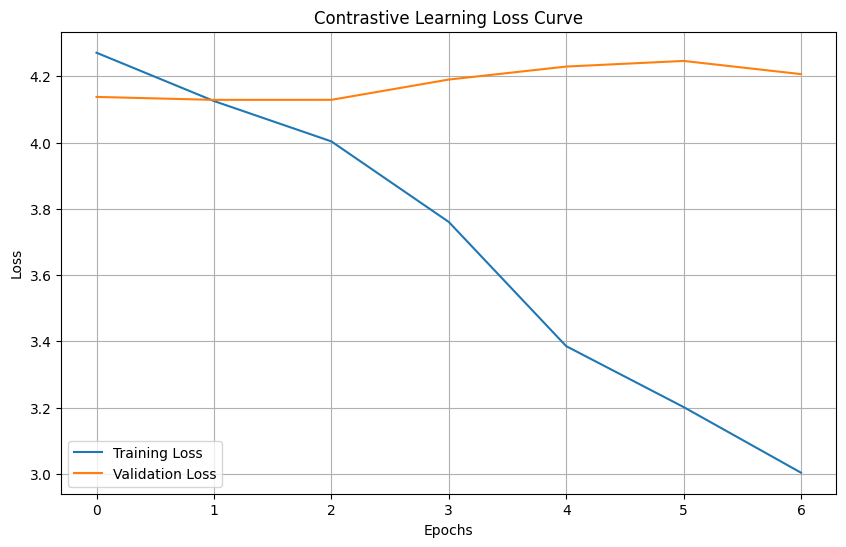

In [ ]:
plt.figure(figsize=(10, 6))
plt.plot(train_history, label='Training Loss')
plt.plot(val_history, label='Validation Loss')
plt.title('Contrastive Learning Loss Curve')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
train_labels_mapped = np.array([label_dict[int(x)] for x in train_labels])
test_labels_mapped = np.array([label_dict[int(x)] for x in test_labels])

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import Normalizer

normalizer = Normalizer(norm='l2') #

X_train = normalizer.fit_transform(train_embeddings)
y_train = train_labels
X_test = normalizer.fit_transform(test_embeddings)
y_test = test_labels


In [ ]:
import numpy as np
from sklearn.mixture import GaussianMixture
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix
from scipy.special import logsumexp

covariance_type = 'full'
default_components = 2
min_samples_for_components = 20

classes = np.unique(y_train)
n_classes = len(classes)


class_counts = {c: np.sum(y_train == c) for c in classes}
total = len(y_train)
class_priors = {c: class_counts[c] / total for c in classes}

gmms = {}
for c in classes:
    Xc = X_train[y_train == c]
    if Xc.shape[0] < 2:
        n_comp = 1
    else:
        n_comp = min(default_components, max(1, Xc.shape[0] // min_samples_for_components))
        n_comp = max(1, n_comp)

    gmm = GaussianMixture(n_components=n_comp, covariance_type=covariance_type, random_state=0)
    try:
        gmm.fit(Xc)
    except Exception as e:
        print(f"Warning: GMM fit failed for class {c} with {Xc.shape[0]} samples, falling back to 1 component. Err: {e}")
        gmm = GaussianMixture(n_components=1, covariance_type=covariance_type, random_state=0)
        gmm.fit(Xc)
    gmms[c] = gmm


log_liks = np.zeros((X_test.shape[0], n_classes))  # each column corresponds to a class in `classes`
for i, c in enumerate(classes):
    # score_samples returns log p(x) for each sample under that class GMM
    log_px = gmms[c].score_samples(X_test)       # shape (n_test,)
    log_prior = np.log(class_priors[c] + 1e-12)  # avoid log(0)
    log_liks[:, i] = log_px + log_prior

# predicted class index, then map back to class label
pred_idx = np.argmax(log_liks, axis=1)
predicted_labels = classes[pred_idx]

# If you want posterior probabilities P(class | x) (softmax over log_liks):
log_norm = logsumexp(log_liks, axis=1, keepdims=True)
log_post = log_liks - log_norm   # normalized log posterior
post_probs = np.exp(log_post)    # shape (n_test, n_classes)

f1_per_class = f1_score(y_test, predicted_labels, average=None, labels=all_classes)
f1_micro = f1_score(y_test, predicted_labels, average='micro')
f1_macro = f1_score(y_test, predicted_labels, average='macro')
f1_weighted = f1_score(y_test, predicted_labels, average='weighted')

print("F1 score per class:", f1_per_class)
print("Micro-average F1 score:", f1_micro)
print("Macro-average F1 score:", f1_macro)
print("Weighted-average F1 score:", f1_weighted)
for c_i, c in enumerate(classes):
    print(f"Class {c}: count(train)={class_counts[c]}, F1={f1_per_class[c_i]:.3f}")


F1 score per class: [0.         0.         0.         0.         0.         0.
 0.         0.         0.14285714 0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.27027027 0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.54545455
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.79069767 0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.        ]
Micro-average F1 score: 0.12367491166077739
Macro-average F1 score: 0.039756355295467345
Weighted-average F1 score: 0.11990141992607271
Class 0: count(train)=60, F1=0.000
Class 1: count(train)=6, F1=0.000
Class 2: count(train)=6, F1=0.000
Class 3: count(t

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in labels with no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Text(0.5, 1.0, 'Effect of K')

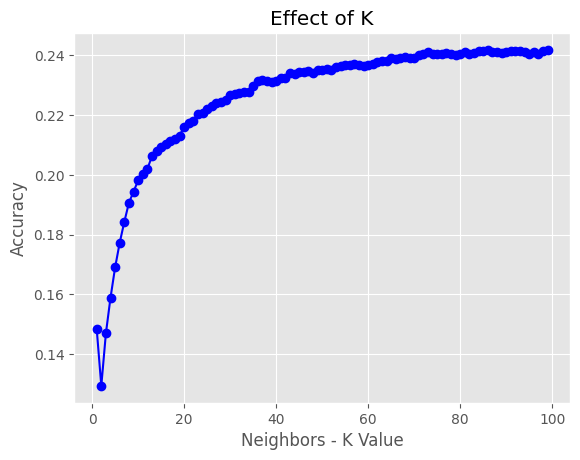

In [ ]:
k_values = list(range(1, 100))
acc_scores = []

from sklearn.model_selection import cross_val_score

for k in k_values:
  KNN = KNeighborsClassifier(n_neighbors=k)

  scores = cross_val_score(KNN, X_train, y_train,
                           scoring='accuracy', cv=5)

  acc_scores.append(np.mean(scores))

plt.style.use("ggplot")

plt.plot(k_values, acc_scores, marker='o', color='blue')
plt.xlabel("Neighbors - K Value")
plt.ylabel("Accuracy")
plt.title("Effect of K")

In [ ]:
knn_classifier = KNeighborsClassifier(n_neighbors=100, metric = 'cosine')
knn_classifier.fit(X_train, y_train)
predicted_labels = knn_classifier.predict(X_test)


In [ ]:
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import f1_score, accuracy_score


mlp = MLPClassifier(
    hidden_layer_sizes=(32,32),
    activation='relu',
    solver='adam',
    alpha=1e-4,
    learning_rate_init=1e-3,
    batch_size=64,
    max_iter=200,
    early_stopping=True,
    n_iter_no_change=10,
    verbose=True
)

# Train
mlp.fit(X_train, y_train)

# Predict
predicted_labels = mlp.predict(X_test)

# Metrics
all_classes = np.arange(72)
f1_per_class = f1_score(y_test, predicted_labels, average=None, labels=all_classes)
f1_micro = f1_score(y_test, predicted_labels, average='micro')
f1_macro = f1_score(y_test, predicted_labels, average='macro')
f1_weighted = f1_score(y_test, predicted_labels, average='weighted')

print("F1 score per class:", f1_per_class)
print("Micro-average F1 score:", f1_micro)
print("Macro-average F1 score:", f1_macro)
print("Weighted-average F1 score:", f1_weighted)

Iteration 1, loss = 4.15390603
Validation score: 0.164062
Iteration 2, loss = 4.09475618
Validation score: 0.195312
Iteration 3, loss = 4.03708541
Validation score: 0.195312
Iteration 4, loss = 3.98063573
Validation score: 0.195312
Iteration 5, loss = 3.91962722
Validation score: 0.195312
Iteration 6, loss = 3.85771212
Validation score: 0.195312
Iteration 7, loss = 3.79913022
Validation score: 0.195312
Iteration 8, loss = 3.74994890
Validation score: 0.195312
Iteration 9, loss = 3.71064406
Validation score: 0.195312
Iteration 10, loss = 3.68076584
Validation score: 0.195312
Iteration 11, loss = 3.65722261
Validation score: 0.195312
Iteration 12, loss = 3.63945756
Validation score: 0.195312
Iteration 13, loss = 3.62231945
Validation score: 0.195312
Validation score did not improve more than tol=0.000100 for 10 consecutive epochs. Stopping.
F1 score per class: [0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.        

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in labels with no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
from sklearn.metrics import f1_score
all_classes = np.arange(72)
f1_per_class = f1_score(y_test, predicted_labels, average=None, labels=all_classes)
f1_micro = f1_score(y_test, predicted_labels, average='micro')
f1_macro = f1_score(y_test, predicted_labels, average='macro')
f1_weighted = f1_score(y_test, predicted_labels, average='weighted')

print("F1 score per class:", f1_per_class)
print("Micro-average F1 score:", f1_micro)
print("Macro-average F1 score:", f1_macro)
print("Weighted-average F1 score:", f1_weighted)


F1 score per class: [0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.23111111 0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.54143646
 0.         0.         0.00716846 0.04347826 0.         0.
 0.         0.         0.         0.46351931 0.         0.
 0.         0.         0.         0.         0.         0.
 0.64171123 0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.15265113 0.        ]
Micro-average F1 score: 0.0960591133004926
Macro-average F1 score: 0.04335574936408785
Weighted-average F1 score: 0.07198580238233442


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in labels with no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


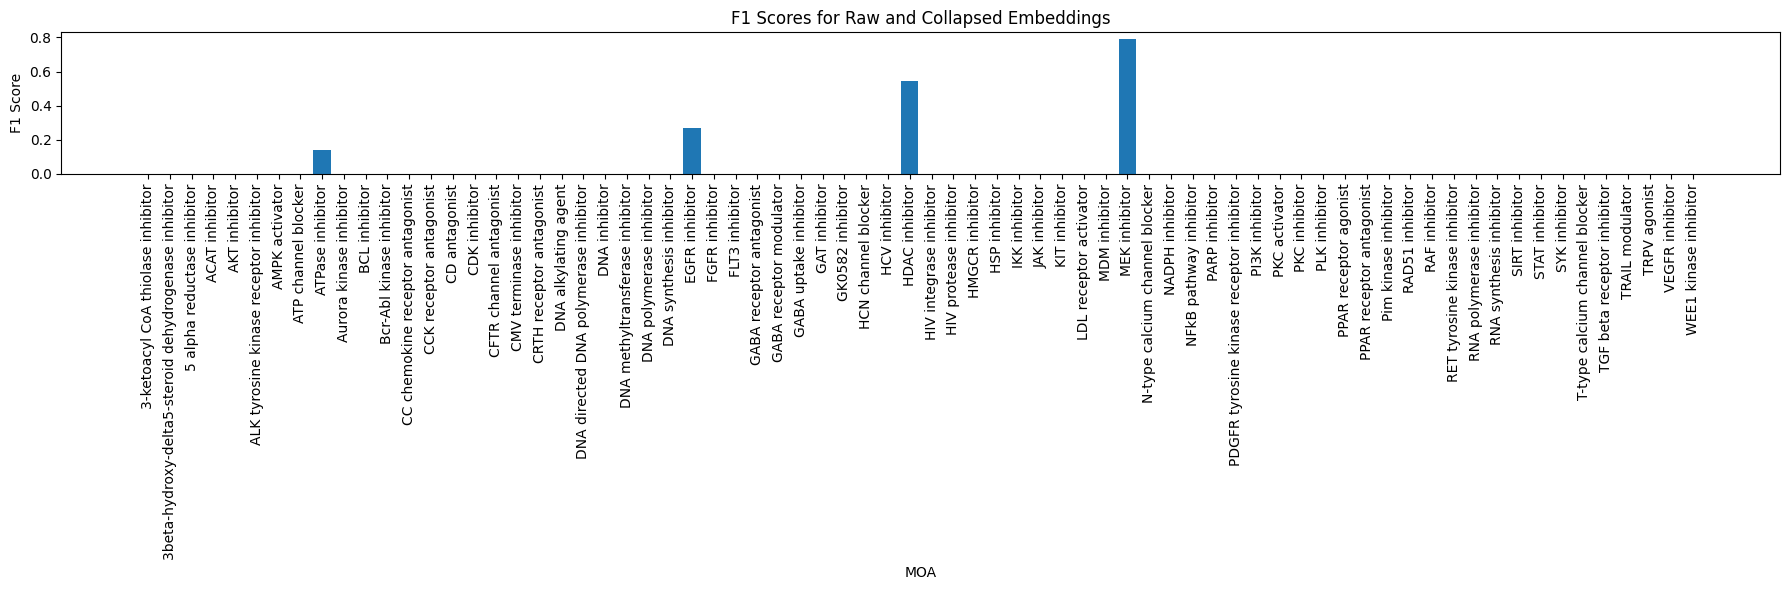

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Corrected line: Use moa_list to get names from indices
all_classes = np.arange(72)
class_names = [moa_list[i] for i in all_classes]

plt.figure(figsize=(18, 6))
plt.bar(class_names, f1_per_class)
plt.xticks(rotation=90)
plt.xlabel("MOA")
plt.ylabel("F1 Score")
plt.title("F1 Scores for Raw and Collapsed Embeddings")
plt.tight_layout()
plt.savefig('raw_collapsed_gmm_F1.png')
plt.show()

In [ ]:
np.save('raw_collapsed_embeddings_gmm_f1.npy', f1_per_class)

In [ ]:
np.save('raw_uncollapsed_training_embeddings.npy', train_embeddings)
np.save('raw_uncollapsed_testing_embeddings.npy', test_embeddings)
np.save('raw_uncollapsed_training_labels.npy', train_labels_mapped)
np.save('raw_uncollapsed_testing_labels.npy', test_labels_mapped)

In [ ]:
group_1 = np.load('uncollapsed_embeddings_gmm_f1.npy')
group_2 = np.load('raw_uncollapsed_embeddings_gmm_f1.npy')
group_3 = np.load('collapsed_embeddings_gmm_f1.npy')
group_4 = np.load('raw_collapsed_embeddings_gmm_f1.npy')

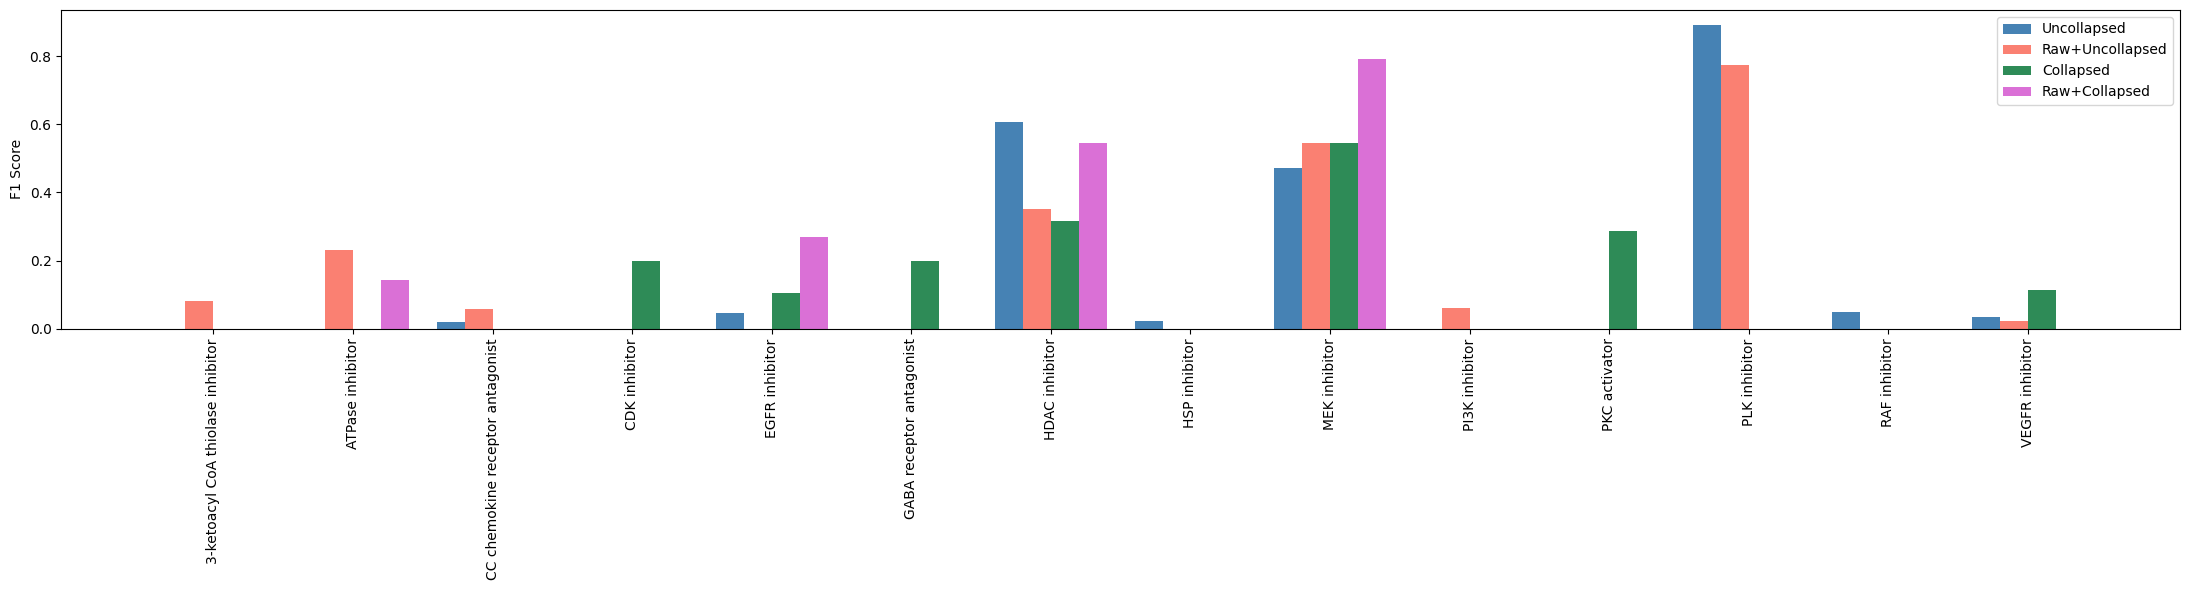

In [ ]:
groups = np.vstack([group_1, group_2, group_3, group_4])
mask = ~(np.all(groups == 0, axis=0))

f1_group1_f = group_1[mask]
f1_group2_f = group_2[mask]
f1_group3_f = group_3[mask]
f1_group4_f = group_4[mask]

class_names_f = [name for i, name in enumerate(class_names) if mask[i]]

groups_filtered = [f1_group1_f, f1_group2_f, f1_group3_f, f1_group4_f]

num_groups = len(groups_filtered)
num_classes = len(class_names_f)

x = np.arange(num_classes)
width = 0.8 / num_groups

plt.figure(figsize=(22, 6))

colors = ["steelblue", "salmon", "seagreen", "orchid"]
group_names =  ["Uncollapsed", "Raw+Uncollapsed", "Collapsed", "Raw+Collapsed"]

for i in range(num_groups):
    plt.bar(
        x + (i - num_groups/2) * width + width/2,
        groups_filtered[i],
        width,
        label=group_names[i],
        color=colors[i]
    )

plt.xticks(x, class_names_f, rotation=90)
plt.ylabel("F1 Score")
plt.legend()
plt.tight_layout()
plt.savefig('cross_comparison_f1.png')
plt.show()



In [7]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

tsne = TSNE(n_components=2, perplexity=30, random_state=0)
emb_tsne = tsne.fit_transform(train_embeddings)

plt.figure(figsize=(7,7))
plt.scatter(emb_tsne[:,0], emb_tsne[:,1], c=train_labels_mapped, s=5, alpha=0.7, cmap="tab20")
#add the legend using the broad_moa_dict
plt.colorbar()
plt.title("t-SNE of Uncollapsed Training Embeddings")
plt.show()

NameError: name 'train_labels_mapped' is not defined

<Figure size 700x700 with 0 Axes>

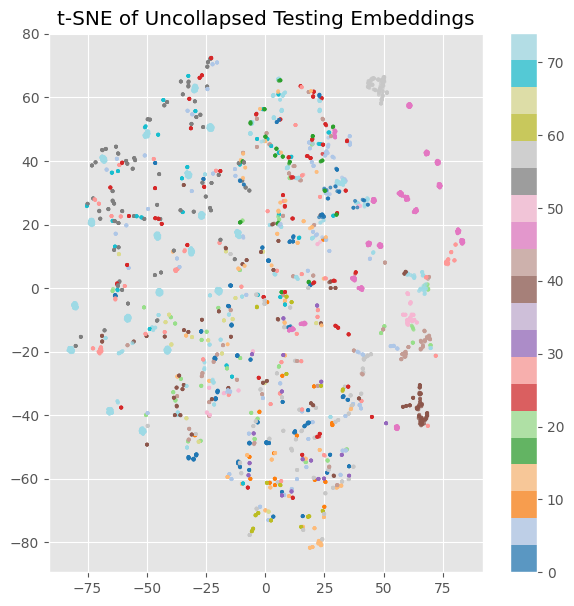

In [ ]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

tsne = TSNE(n_components=2, perplexity=30, random_state=0)
emb_tsne = tsne.fit_transform(test_embeddings)

plt.figure(figsize=(7,7))
plt.scatter(emb_tsne[:,0], emb_tsne[:,1], c=test_labels_mapped, s=5, alpha=0.7, cmap="tab20")
#add the legend using the broad_moa_dict
plt.colorbar()
plt.title("t-SNE of Uncollapsed Testing Embeddings")
plt.show()


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


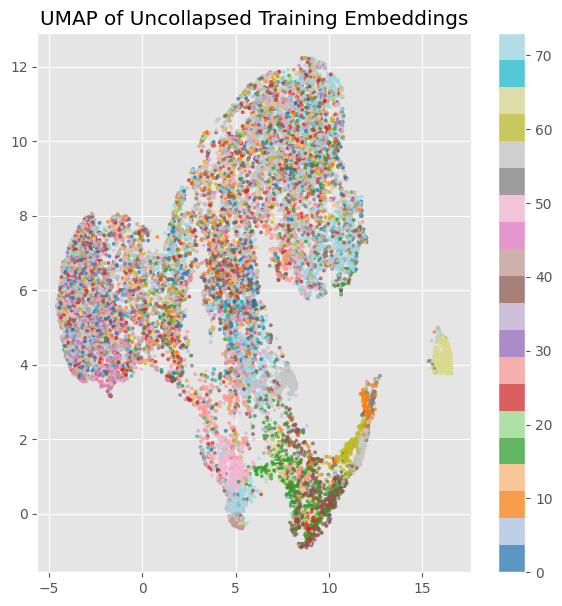

In [ ]:
import umap

um = umap.UMAP(
    n_neighbors=15,
    min_dist=0.1,
    metric='cosine',
    random_state=0
)

emb_umap = um.fit_transform(train_embeddings)

plt.figure(figsize=(7,7))
plt.scatter(emb_umap[:,0], emb_umap[:,1], c=train_labels_mapped, s=5, alpha=0.7, cmap="tab20")
#add the broad_moa_dict legend here as label
plt.colorbar()
plt.title("UMAP of Uncollapsed Training Embeddings")
plt.show()
